# 00 — Environment and end-to-end smoke test

This notebook performs a **new simulation from scratch**. It does not read any trajectory or result file from the paper release. The purpose is to verify the Python environment, the synthetic-flow generator, particle integration, the mass ellipse, and the minimum-volume enclosing ellipse before starting the expensive paper campaign.

In [1]:
from pathlib import Path
import os, sys

def find_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Repository root not found. Start Jupyter inside the extracted directory.")

ROOT = find_root(Path.cwd())
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print("ROOT =", ROOT)


ROOT = /mnt/data/work_release_v3/LagrangianEllipsoid_Corrected_Release_v3/2_github_repository


In [2]:
import platform, json
import numpy as np
import scipy
import matplotlib
import pandas as pd

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Pandas:", pd.__version__)

Python: 3.13.5
NumPy: 2.3.5
SciPy: 1.17.0
Matplotlib: 3.10.8
Pandas: 2.2.3


In [3]:
from lagrangian_ellipsoid.core import FlowConfig, SimConfig, simulate, derive

# Deliberately small parameters: this is a pipeline test, not a paper dataset.
flow = FlowConfig(k_max=16, zeta=1/3, dt=0.02, ngrid=64, tau_model="turnover")
cfg = SimConfig(
    flow=flow,
    max_time=0.8,
    n_particles=120,
    subsets=(120,),
    r0_over_uv=1.0,
    record_stride=2,
    mee_tol=1e-4,
)
run = simulate(cfg, seed=20260716)
print("records:", len(run["time"]), "stop reason:", str(run["stop_reason"]))
print("initial radius:", float(run["r0"]))

records: 21 stop reason: max_time
initial radius: 0.39269908169872414


In [4]:
from pathlib import Path
import numpy as np

outdir = ROOT / "data" / "smoke"
outdir.mkdir(parents=True, exist_ok=True)
path = outdir / "smoke_seed20260716.npz"
np.savez_compressed(path, **run)
print("saved", path.relative_to(ROOT))

saved data/smoke/smoke_seed20260716.npz


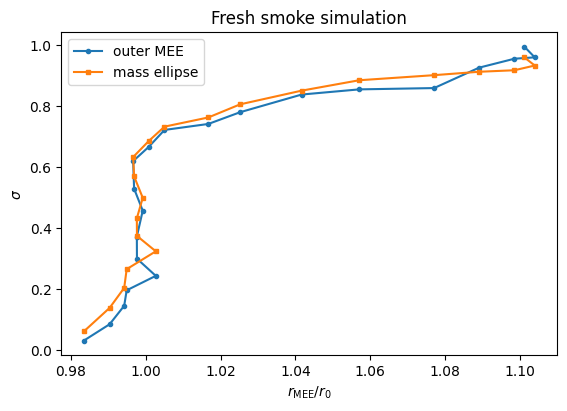

Smoke test passed.


In [5]:
import matplotlib.pyplot as plt

mee = derive(run, "mee")
mass = derive(run, "cov")
rr = mee["r"] / float(run["r0"])
assert np.all(np.isfinite(mee["sigma"]))
assert np.all(np.isfinite(mass["sigma"]))
assert np.all(mee["r"] > 0) and np.all(mass["r"] > 0)

fig, ax = plt.subplots(figsize=(6.4,4.2))
ax.plot(rr, mee["sigma"], marker="o", ms=3, label="outer MEE")
ax.plot(rr, mass["sigma"], marker="s", ms=3, label="mass ellipse")
ax.set_xlabel(r"$r_{\rm MEE}/r_0$")
ax.set_ylabel(r"$\sigma$")
ax.legend()
ax.set_title("Fresh smoke simulation")
plt.show()
print("Smoke test passed.")